# Section 3: Build, Train or Estimate the ML Model --> Chapter 14. Time Series Forecasting

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
!pip install arch
!pip install pmdarima

---

☑ **Import libraries**

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import time
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller


import warnings
from statsmodels.tsa.stattools import kpss

from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white


import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan


import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_goldfeldquandt

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SARIMAX
from pmdarima import metrics as pm_metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from arch import arch_model
from itertools import zip_longest
from sklearn.linear_model import LinearRegression
import warnings
import time
from arch import arch_model

from pmdarima import auto_arima

# Suppress all warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose






#2. Univariate Time series

##2.1. Model Preparation Steps

###Step 2a: Model Preparation 1: Get data

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width) + "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S3_Ch14_Timeseries.csv'
    dataLink = 'https://drive.google.com/open?id=16r63v-Ctdb1kmE_hGbKrctY4qnGBRznq'   # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)

    return df_rawdata

# Step 1. Get Data
timeseries_df = _1_get_data()
# Print Header
print_pretty_header(f"Forecasting Time-series", "All Data")

timeseries_df

####################################################################################################

                                      Forecasting Time-series                                       

                                              All Data                                              

####################################################################################################



,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,20.799999,21.474001,20.733334,21.368668,21.368668,65283000
1,2018-01-03,21.400000,21.683332,21.036667,21.150000,21.150000,67822500
2,2018-01-04,20.858000,21.236668,20.378668,20.974667,20.974667,149194500
3,2018-01-05,21.108000,21.149332,20.799999,21.105333,21.105333,68868000
4,2018-01-08,21.066668,22.468000,21.033333,22.427334,22.427334,147891000
...,...,...,...,...,...,...,...
1375,2023-06-21,275.130005,276.989990,257.779999,259.459991,259.459991,211797100
1376,2023-06-22,250.770004,265.000000,248.250000,264.609985,264.609985,166875900
1377,2023-06-23,259.290009,262.450012,252.800003,256.600006,256.600006,176584100
1378,2023-06-26,250.070007,258.369995,240.699997,241.050003,241.050003,179990600


###Step 2b: Model Preparation 2: Split data for time series & visualizing it

In [ ]:
import pandas as pd

def _2_splitdata(timeseries_df):
    # Sort the data chronologically
    timeseries_df = timeseries_df.sort_values(by='Date')

    # Convert 'Date' to datetime and set it as the index
    timeseries_df['Date'] = pd.to_datetime(timeseries_df['Date'])
    timeseries_df.set_index('Date', inplace=True)

    data_series = timeseries_df['Adj Close']

    train_size_lim = int(len(data_series) * 0.8)

    # Split the data into training and testing sets
    df_train_data = timeseries_df.iloc[:train_size_lim]
    df_test_data = timeseries_df.iloc[train_size_lim:]

    # Calculate the rolling 7-day mean for the first portion of the training data
    df_7d = df_train_data['Adj Close'].rolling(7, center=True).mean()

    return df_train_data, df_test_data, df_7d

# Filter data before January 1, 2020
filtered_timeseries_df = timeseries_df[timeseries_df['Date'] >= '2020-01-01']

# Call the function to split the filtered data
df_train_data, df_test_data, df_7d = _2_splitdata(filtered_timeseries_df)

# Print Header
print_pretty_header("Forecasting Time-series", "Training Data")

# Print the training data
df_train_data


####################################################################################################

                                      Forecasting Time-series                                       

                                           Training Data                                            

####################################################################################################



,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,28.299999,28.713333,28.114000,28.684000,28.684000,142981500
2020-01-03,29.366667,30.266666,29.128000,29.534000,29.534000,266677500
2020-01-06,29.364668,30.104000,29.333332,30.102667,30.102667,151995000
2020-01-07,30.760000,31.441999,30.224001,31.270666,31.270666,268231500
2020-01-08,31.580000,33.232666,31.215334,32.809334,32.809334,467164500
...,...,...,...,...,...,...
2022-10-06,239.440002,244.580002,235.350006,238.130005,238.130005,69298400
2022-10-07,233.940002,234.570007,222.020004,223.070007,223.070007,83916800
2022-10-10,223.929993,226.990005,218.360001,222.960007,222.960007,67925000


In [ ]:
df_test_data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-10-13,208.300003,222.990005,206.220001,221.720001,221.720001,91483000
2022-10-14,224.009995,226.259995,204.160004,204.990005,204.990005,94124500
2022-10-17,210.039993,221.860001,209.449997,219.350006,219.350006,79428800
2022-10-18,229.500000,229.820007,217.250000,220.190002,220.190002,75891900
2022-10-19,219.800003,222.929993,217.779999,222.039993,222.039993,66571500
...,...,...,...,...,...,...
2023-06-21,275.130005,276.989990,257.779999,259.459991,259.459991,211797100
2023-06-22,250.770004,265.000000,248.250000,264.609985,264.609985,166875900
2023-06-23,259.290009,262.450012,252.800003,256.600006,256.600006,176584100


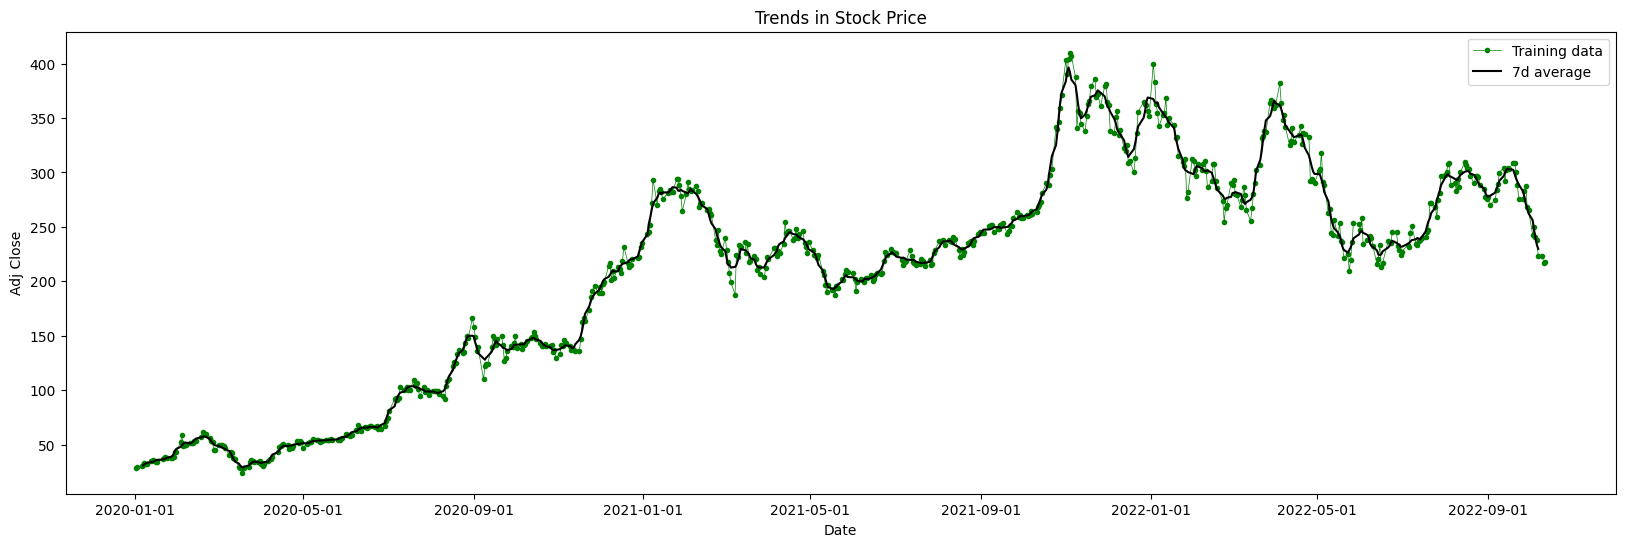

In [ ]:
def _3_visualize_training_data(df_train_data, df_test_data, df_7d):
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Adjust the format as needed

    ax.plot(df_train_data['Adj Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Training data')
    # ax.plot(df_test_data['Adj Close'], color='red' , marker='.', linestyle='-', linewidth=0.5, label='Test data')
    ax.plot(df_7d, color='black', marker='', markersize=4, linestyle='-', label='7d average')

    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close')
    ax.set_title('Trends in Stock Price')

    plt.show()  # Display the plot without returning DataFrames

_3_visualize_training_data(df_train_data, df_test_data, df_7d)

###Step 2c: Model Preparation 3: Complete data pre-processing steps

There is no code for this here - replicate from Chapter 2 through 8.

## 2.2. How to determine non-stationarity in data?


### 2.2.1. Stochastic Trends or Unit Roots



####Step 3a. Detect non-stationarity with Augmented Dickey-Fuller Test (ADF Test)

In [ ]:
def adf_test(data, data_name):
    # Assuming your time series is in the variable 'data'
    result = adfuller(data['Adj Close'])

    # Extracting the p-value from the test result
    p_value = result[1]

    # Testing the p-value against a chosen significance level
    if p_value < 0.05:
        print(f"Augmented Dickey-Fuller Test (ADF Test) for {data_name}: The data is stationary.")
    else:
        print(f"Augmented Dickey-Fuller Test (ADF Test) for {data_name}: The data is non-stationary.")


# Print Header
print_pretty_header(f"Test for Stochastic Trends or Unit Roots", "Augmented Dickey-Fuller Test (ADF Test)")

# Run ADF test
adf_test(df_train_data, data_name="Training Data")
adf_test(df_test_data, data_name="Testing Data")

####################################################################################################

                              Test for Stochastic Trends or Unit Roots                              

                              Augmented Dickey-Fuller Test (ADF Test)                               

####################################################################################################

Augmented Dickey-Fuller Test (ADF Test) for Training Data: The data is non-stationary.
Augmented Dickey-Fuller Test (ADF Test) for Testing Data: The data is non-stationary.


####Step 3b.Detect non-stationarity with Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS)

In [ ]:
def kpss_test(data, data_name="Data"):
    # Suppressing InterpolationWarning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = kpss(data['Adj Close'])

    # Extracting the p-value from the test result
    p_value = result[1]

    # Testing the p-value against a chosen significance level
    if p_value < 0.05:
        print(f"Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS) for {data_name}: The data is non-stationary.")
    else:
        print(f"Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS) for {data_name}: The data is stationary.")

# Print Header
print_pretty_header(f"Test for Stochastic Trends or Unit Roots", "Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS)")

# Run KPSS test
kpss_test(df_train_data, data_name="Training Data")
kpss_test(df_test_data, data_name="Testing Data")

####################################################################################################

                              Test for Stochastic Trends or Unit Roots                              

                           Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS)                            

####################################################################################################

Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS) for Training Data: The data is non-stationary.
Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS) for Testing Data: The data is stationary.


### 2.2.2. Trends

####Step 4a: Detect long-term trends with linear regression

####################################################################################################

                                           Detect Trends                                            

                           Detect long-term trends with linear regression                           

####################################################################################################



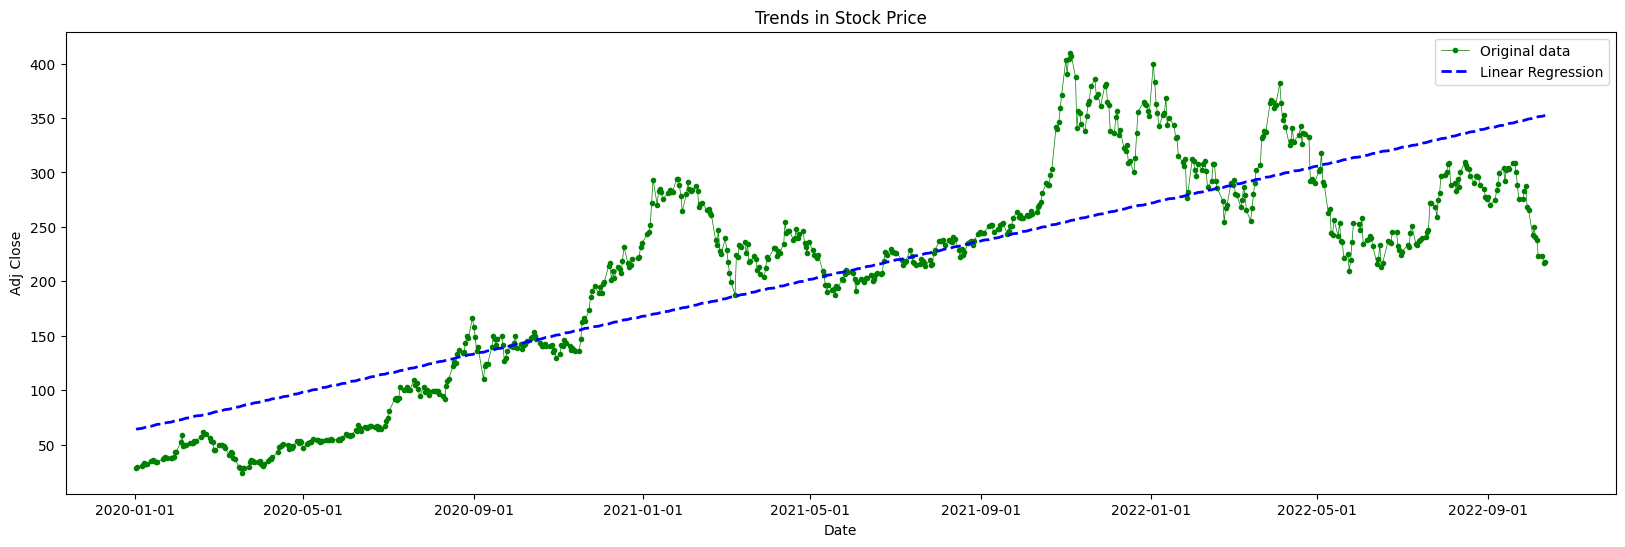

In [ ]:
def _linear_reg(df_train_data):

    # Create the ax object
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Adjust the format as needed

    # Perform linear regression on entire data
    X = np.arange(len(df_train_data)).reshape(-1, 1)
    y = df_train_data['Adj Close'].values.reshape(-1, 1)  # Reshape y to match X's shape
    model = LinearRegression()
    model.fit(X, y)

    # Predict and plot the linear regression line
    X_pred = np.arange(len(df_train_data)).reshape(-1, 1)
    y_pred = model.predict(X_pred)

    ax.plot(df_train_data.index, df_train_data['Adj Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Original data')
    ax.plot(df_train_data.index, y_pred, color='blue', linestyle='--', linewidth=2, label='Linear Regression')

    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close')
    ax.set_title('Trends in Stock Price')
    plt.show()

# Print Header
print_pretty_header(f"Detect Trends", "Detect long-term trends with linear regression")

# Assuming df_train_data is a DataFrame with 'Date' as index and 'Adj Close' as a column
_linear_reg(df_train_data)


####Step 4b: Detect short-term trends with moving averages

####################################################################################################

                                      Detect Short-term Trends                                      

                            Detect short-term trends with Moving Average                            

####################################################################################################



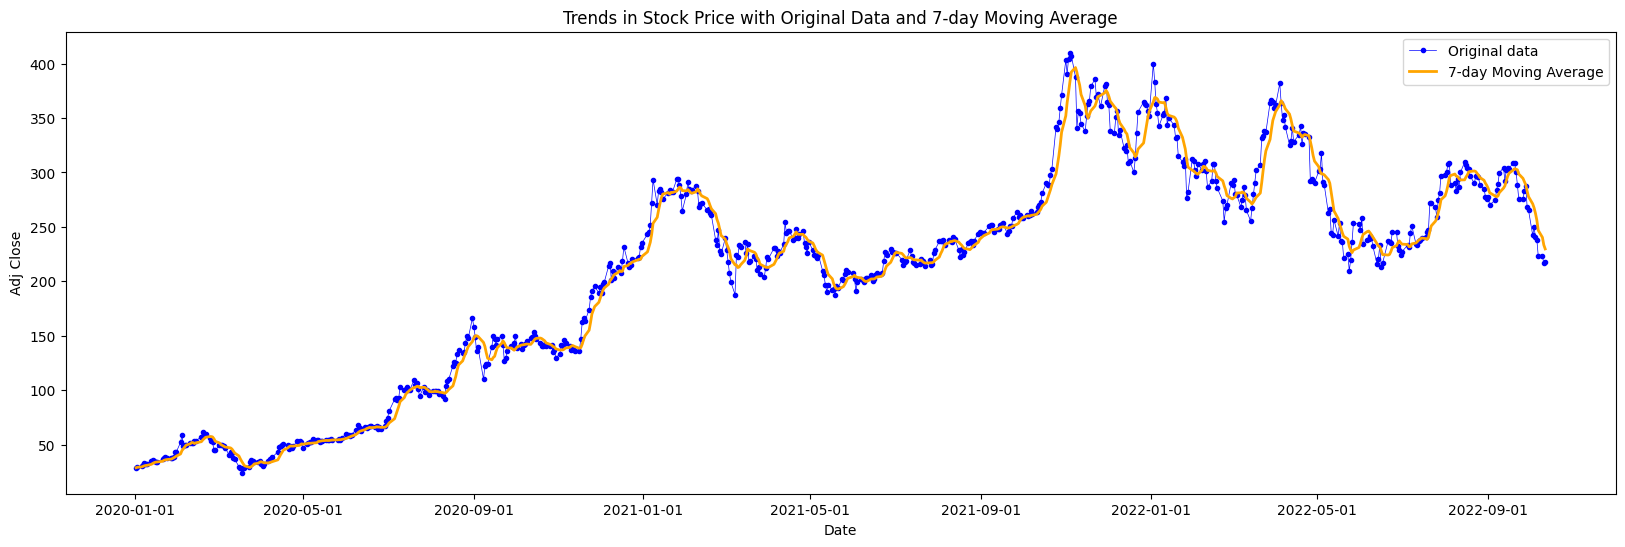

In [ ]:
def _visualize_7d_moving_average(df_train_data, window_size=7):

    # Create the ax object
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Adjust the format as needed

    # Plot original data
    ax.plot(df_train_data.index, df_train_data['Adj Close'], color='blue', marker='.', linestyle='-', linewidth=0.5, label='Original data')

    # Calculate and plot 7-day moving average
    df_train_data['MA'] = df_train_data['Adj Close'].rolling(window=window_size, min_periods=1).mean()
    ax.plot(df_train_data.index, df_train_data['MA'], color='orange', linestyle='-', linewidth=2, label=f'{window_size}-day Moving Average')

    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close')
    ax.set_title('Trends in Stock Price with Original Data and 7-day Moving Average')
    plt.show()

print_pretty_header(f"Detect Short-term Trends", "Detect short-term trends with Moving Average")
# Assuming df_train_data is a DataFrame with 'Date' as index and 'Adj Close' as a column
_visualize_7d_moving_average(df_train_data, window_size=7)


### 2.2.3. Seasonality

####Step 5a: Detect seasonality with ACF and PACF

####################################################################################################

                                         Detect Seasonality                                         

                                Detect seasonality with ACF and PACF                                

####################################################################################################



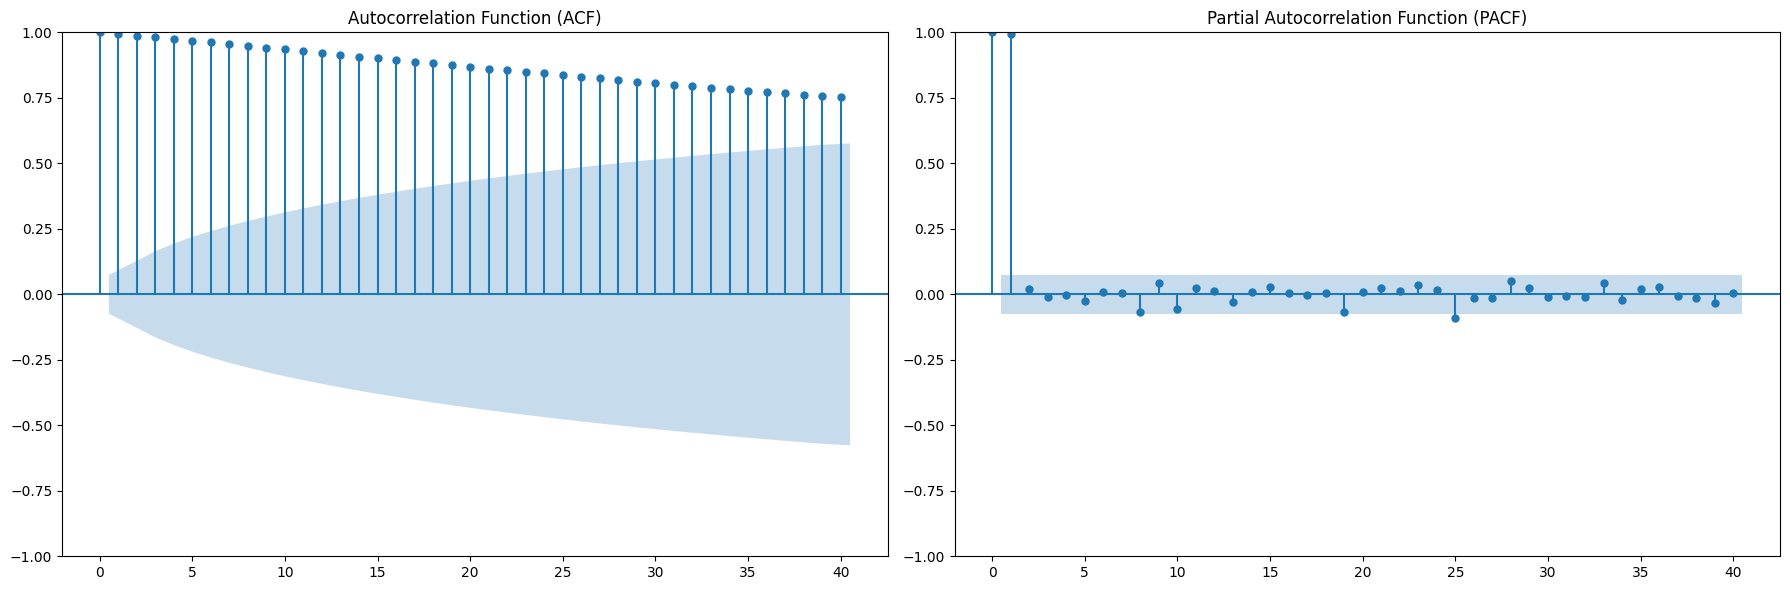

In [ ]:
def visualize_seasonality_acf_pacf(df_train_data, lags):
    data_series = df_train_data['Adj Close']

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot ACF
    plot_acf(data_series, lags=lags, ax=ax1, title='Autocorrelation Function (ACF)')

    # Plot PACF
    plot_pacf(data_series, lags=lags, ax=ax2, title='Partial Autocorrelation Function (PACF)')

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Assuming df_train_data is your DataFrame with 'Date' as a column and 'Adj Close' as a column
lags = 40
print_pretty_header(f"Detect Seasonality", "Detect seasonality with ACF and PACF")
visualize_seasonality_acf_pacf(df_train_data, lags)


### 2.2.4. External Events



####Step 6a: Visualize external events

####################################################################################################

                                     Visualize External Events                                      

                                      Overlay External Events                                       

####################################################################################################



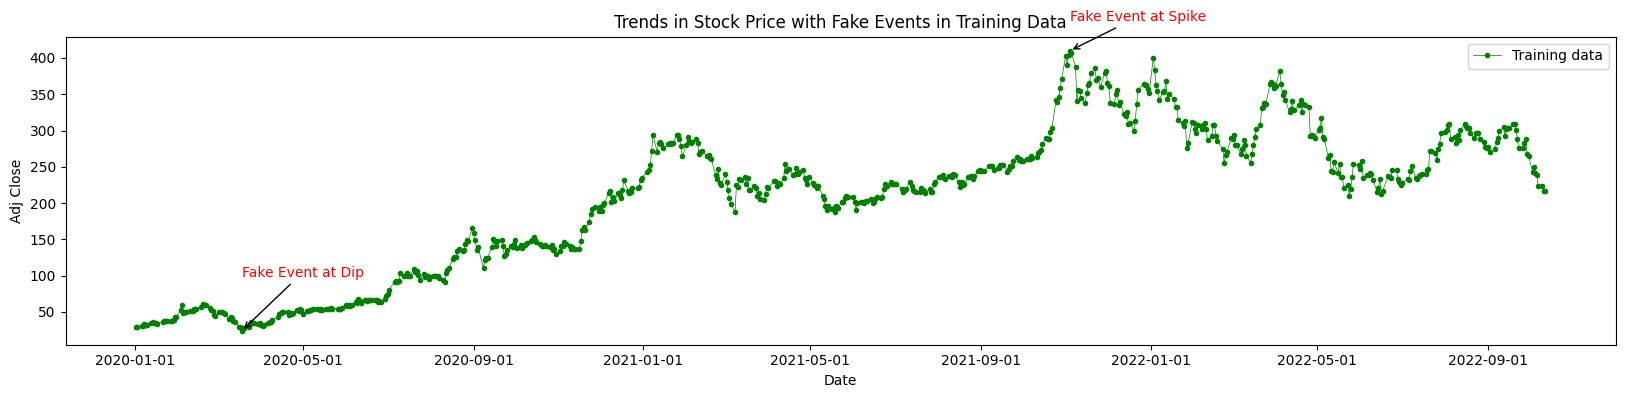

In [ ]:
def _visualize_external_events(df_train_data):

    # Create fake events for training data at spikes or dips
    fake_events = [
        (df_train_data['Adj Close'].idxmax(), 'Fake Event at Spike'),
        (df_train_data['Adj Close'].idxmin(), 'Fake Event at Dip')
    ]

    # Plot training data
    fig, ax = plt.subplots(figsize=(20, 4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Adjust the format as needed

    ax.plot(df_train_data['Adj Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Training data')

    # Plot fake events on the training data plot
    for event_date, event_label in fake_events:
        if 'Spike' in event_label:
            ax.annotate(event_label, xy=(event_date, df_train_data['Adj Close'].max()), xytext=(event_date, df_train_data['Adj Close'].max() * 1.1),
                        arrowprops=dict(facecolor='black', arrowstyle='->'), color='red')
        else:
            ax.annotate(event_label, xy=(event_date, df_train_data['Adj Close'].min()), xytext=(event_date, df_train_data['Adj Close'].min() * 4.1),
                        arrowprops=dict(facecolor='black', arrowstyle='->'), color='red')

    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close')
    ax.set_title('Trends in Stock Price with Fake Events in Training Data')

#Print Header
print_pretty_header(f"Visualize External Events", "Overlay External Events")
_visualize_external_events(df_train_data)

### 2.2.5. Volatility

####Step 7a: Detect volatility with standard deviation, percentage changes, Bollinger Bands

####################################################################################################

                                        Visualize Volatality                                        

           Detect volatility with standard deviation, percentage changes, Bollinger Bands           

####################################################################################################



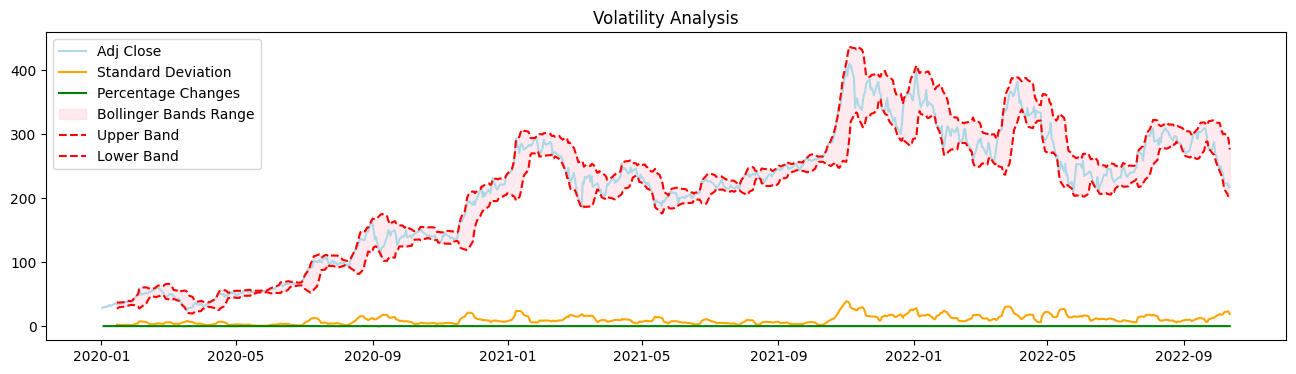

In [ ]:
def visualize_volatility(df_train_data):
    window_size = 10

    # Standard Deviation
    rolling_std = df_train_data['Adj Close'].rolling(window=window_size).std()

    # Percentage Changes
    percentage_changes = df_train_data['Adj Close'].pct_change()

    # Bollinger Bands
    rolling_mean = df_train_data['Adj Close'].rolling(window=window_size).mean()
    upper_band = rolling_mean + (2 * rolling_std)
    lower_band = rolling_mean - (2 * rolling_std)

    # Plotting
    plt.figure(figsize=(16, 4))

    # Original Time Series
    plt.plot(df_train_data.index, df_train_data['Adj Close'], label='Adj Close', color='lightblue')

    # Standard Deviation
    plt.plot(df_train_data.index, rolling_std, label='Standard Deviation', color='orange')

    # Percentage Changes
    plt.plot(df_train_data.index, percentage_changes, label='Percentage Changes', color='green')

    # Bollinger Bands
    plt.fill_between(df_train_data.index, lower_band, upper_band, color='pink', alpha=0.3, label='Bollinger Bands Range')
    plt.plot(df_train_data.index, upper_band, label='Upper Band', color='red', linestyle='--')
    plt.plot(df_train_data.index, lower_band, label='Lower Band', color='red', linestyle='--')

    plt.title('Volatility Analysis')
    plt.legend()
    plt.show()

#Print Header
print_pretty_header(f"Visualize Volatality", "Detect volatility with standard deviation, percentage changes, Bollinger Bands")

# Assuming df_train_data is your DataFrame with 'Date' as index and 'Adj Close' as a column
visualize_volatility(df_train_data)


####Step 7b: Detect volatility with Average True Range (ATR), and Volatility Index (VIX)

####################################################################################################

                                        Visualize Volatality                                        

            Detect volatility with Average True Range (ATR), and Volatility Index (VIX)             

####################################################################################################



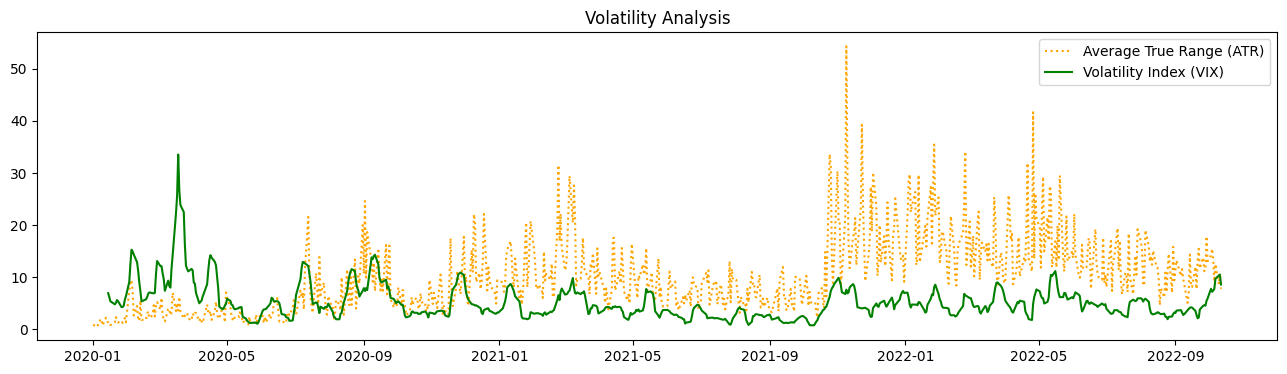

In [ ]:
def visualize_volatility(df_train_data):
    window_size = 10

    # Standard Deviation
    rolling_std = df_train_data['Adj Close'].rolling(window=window_size).std()

    # Percentage Changes
    percentage_changes = df_train_data['Adj Close'].pct_change()

    # Bollinger Bands
    rolling_mean = df_train_data['Adj Close'].rolling(window=window_size).mean()
    upper_band = rolling_mean + (2 * rolling_std)
    lower_band = rolling_mean - (2 * rolling_std)

    # Average True Range (ATR)
    df_train_data['ATR'] = df_train_data['High'] - df_train_data['Low']

    # Volatility Index (VIX)
    df_train_data['VIX'] = (rolling_std / df_train_data['Adj Close']) * 100

    # Plotting
    plt.figure(figsize=(16, 4))

    # Average True Range (ATR)
    plt.plot(df_train_data.index, df_train_data['ATR'], label='Average True Range (ATR)', color='orange', linestyle='dotted')

    # Volatility Index (VIX)
    plt.plot(df_train_data.index, df_train_data['VIX'], label='Volatility Index (VIX)', color='green', linestyle='-')

    plt.title('Volatility Analysis')
    plt.legend()
    plt.show()

#Print Header
print_pretty_header(f"Visualize Volatality", "Detect volatility with Average True Range (ATR), and Volatility Index (VIX)")

visualize_volatility(df_train_data)


### 2.2.6. Heteroskedasticity

####Step 8a: Detect heteroskedasticity with White Test

In [ ]:
# Assuming df_train_data is your DataFrame with 'Adj Close' as the univariate time series
y = df_train_data['Adj Close']

# Fit the OLS model without additional independent variables
X = sm.add_constant(pd.Series(range(len(y)), index=y.index))  # Adding a constant term
model = sm.OLS(y, X).fit()

# Obtain residuals
residuals = model.resid

# Perform White Test for heteroskedasticity
white_test_statistic, white_test_p_value, fstat, fp_value = het_white(residuals, exog=X)

# Set significance level
alpha = 0.05

#Print Header
print_pretty_header(f"Detect heteroskedasticity", "White Test")

# Display the results
print("White Test Statistic:", white_test_statistic)
print("White Test P-Value:", white_test_p_value)
print("F-Statistic:", fstat)
print("F-Test P-Value:", fp_value)


# Check for heteroskedasticity based on the p-value
if white_test_p_value < alpha:
    print(f"The test suggests heteroskedasticity.")
else:
    print(f"The test suggests homoskedasticity.")


####################################################################################################

                                     Detect heteroskedasticity                                      

                                             White Test                                             

####################################################################################################

White Test Statistic: 57.91382231190604
White Test P-Value: 2.6556648906621736e-13
F-Statistic: 31.429573030969863
F-Test P-Value: 8.518317685494764e-14
The test suggests heteroskedasticity.


####Step 8b: Detect heteroskedasticity with Breusch-Pagan test


In [ ]:
# Assuming df_train_data is your DataFrame with 'Adj Close' as the univariate time series
y = df_train_data['Adj Close']

# Fit the OLS model without additional independent variables
X = sm.add_constant(pd.Series(range(len(y)), index=y.index))  # Adding a constant term
model = sm.OLS(y, X).fit()

# Obtain residuals
residuals = model.resid

# Perform Breusch-Pagan Test for heteroskedasticity
bp_test_statistic, bp_test_p_value, _, _ = het_breuschpagan(residuals, exog_het=X)

# Set significance level
alpha = 0.05

#Print Header
print_pretty_header(f"Detect heteroskedasticity", "Breusch-Pagan Test")

# Display the results
print("Breusch-Pagan Test Statistic:", bp_test_statistic)
print("Breusch-Pagan Test P-Value:", bp_test_p_value)

# Check for heteroskedasticity based on the p-value
if bp_test_p_value < alpha:
    print("The test suggests heteroskedasticity.")
else:
    print("The test suggests homoskedasticity.")


####################################################################################################

                                     Detect heteroskedasticity                                      

                                         Breusch-Pagan Test                                         

####################################################################################################

Breusch-Pagan Test Statistic: 54.71323854462112
Breusch-Pagan Test P-Value: 1.3946366462155766e-13
The test suggests heteroskedasticity.


####Step 8c: Detect heteroskedasticity with Goldfeld-Quandt test


In [ ]:
# Assuming df_train_data is your DataFrame with 'Adj Close' as the univariate time series
y = df_train_data['Adj Close']

# Fit the OLS model without additional independent variables
X = sm.add_constant(pd.Series(range(len(y)), index=y.index))  # Adding a constant term
model = sm.OLS(y, X).fit()

# Obtain residuals
residuals = model.resid

# Perform Goldfeld-Quandt Test for heteroskedasticity
gq_test_statistic, gq_test_p_value, split_point = het_goldfeldquandt(residuals, X)

# Set significance level
alpha = 0.05

#Print Header
print_pretty_header(f"Detect heteroskedasticity", "Goldfeld-Quandt Test")

# Display the results
print("Goldfeld-Quandt Test Statistic:", gq_test_statistic)
print("Goldfeld-Quandt Test P-Value:", gq_test_p_value)

# Check for heteroskedasticity based on the p-value
if gq_test_p_value < alpha:
    print("Goldfeld-Quandt Test suggests heteroskedasticity.")
else:
    print("Goldfeld-Quandt Test suggests homoskedasticity.")


####################################################################################################

                                     Detect heteroskedasticity                                      

                                        Goldfeld-Quandt Test                                        

####################################################################################################

Goldfeld-Quandt Test Statistic: 2.670328827980158
Goldfeld-Quandt Test P-Value: 1.249926387612324e-19
Goldfeld-Quandt Test suggests heteroskedasticity.


##2.4 Prioritize and rectify

###2.4.1. Determine appropriate differencing, autoregressive, and moving average order


####Step 9a: Determine appropriate differencing, autoregressive, and moving average order

###2.4.2. Differencing


####Step 9b: First Order Differencing

####################################################################################################

                    Correct for Stochastic Trends or Unit Roots - Training Data                     

                                   First-Order Differenced Series                                   

####################################################################################################



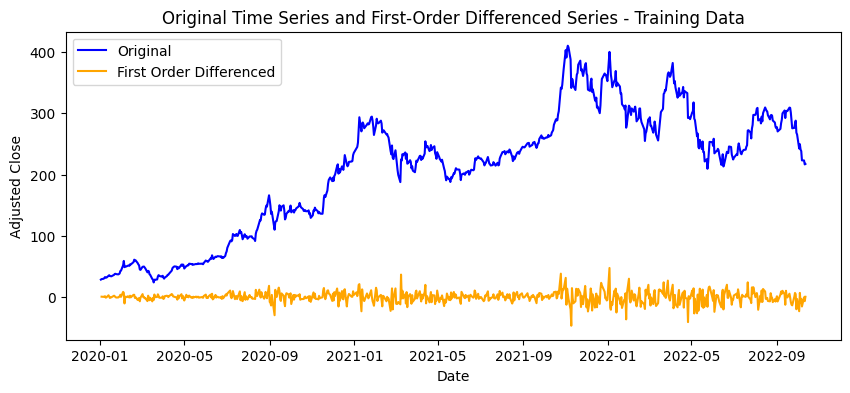

In [ ]:
def first_order_differencing(data, data_name):
    # Assuming your DataFrame has a column named 'Adj Close' for the time series
    data.index = pd.to_datetime(data.index)  # Convert the index to datetime

    # Plot the original time series and the differenced series
    plt.figure(figsize=(10, 4))

    # Plot the original time series in blue
    plt.plot(data.index, data['Adj Close'], label='Original', color='blue')

    # Print Header
    print_pretty_header(f"Correct for Stochastic Trends or Unit Roots - {data_name}", "First-Order Differenced Series")

    # Plot the first-order differenced series in orange
    differenced_series = data['Adj Close'].diff().dropna()
    plt.plot(data.index[1:], differenced_series, label='First Order Differenced', color='orange')

    plt.title(f'Original Time Series and First-Order Differenced Series - {data_name}')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close')
    plt.legend()
    plt.show()
    return differenced_series

# Training Data
differenced_Adj_Close_train = first_order_differencing(df_train_data, data_name="Training Data")

# # To apply differencing to the test data, use the last observation from the training data
# base_value = df_train_data['Adj Close'].iloc[-1]

# # Apply differencing to test data
# df_test_data['Differenced_Column'] = df_test_data['Adj Close'].diff() + base_value

# # Test Data
# differenced_Adj_Close_test = first_order_differencing(df_test_data, data_name="Test Data")


####Step 9c: Higher(Third) Order Differencing (Example)

####################################################################################################

                         Correct for Stochastic Trends or Unit Roots - Data                         

                                     3-Order Differenced Series                                     

####################################################################################################



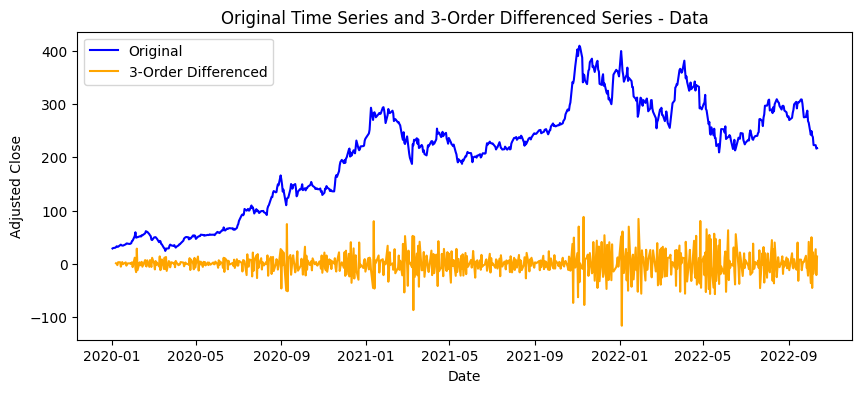

In [ ]:
def higher_order_differencing(data, order, data_name="Data"):

    data.index = pd.to_datetime(data.index)  # Convert the index to datetime

    # Perform higher-order differencing
    differenced_series = data['Adj Close']
    for i in range(order):
        differenced_series = differenced_series.diff().dropna()

    # Plot the original time series and the higher-order differenced series
    plt.figure(figsize=(10, 4))

    # Print Header
    print_pretty_header(f"Correct for Stochastic Trends or Unit Roots - {data_name}", f"{order}-Order Differenced Series")

    # Plot the original time series in blue
    plt.plot(data.index, data['Adj Close'], label='Original', color='blue')

    # Plot the higher-order differenced series in orange
    plt.plot(data.index[order:], differenced_series, label=f'{order}-Order Differenced', color='orange')

    plt.title(f'Original Time Series and {order}-Order Differenced Series - {data_name}')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close')
    plt.legend()
    plt.show()

# Assuming df_train_data is your training DataFrame
higher_order_differencing(df_train_data, order=3)
# # To apply differencing to the test data, use the last observation from the training data
# base_value = df_train_data['Adj Close'].iloc[-1]

# # Apply differencing to test data
# df_test_data['Differenced_Column'] = df_test_data['Adj Close'].diff() + base_value

# # Test Data
# differenced_Adj_Close_test = higher_order_differencing(df_test_data, order=3)



###2.4.3. Detrending

####Step 9d: Detrending

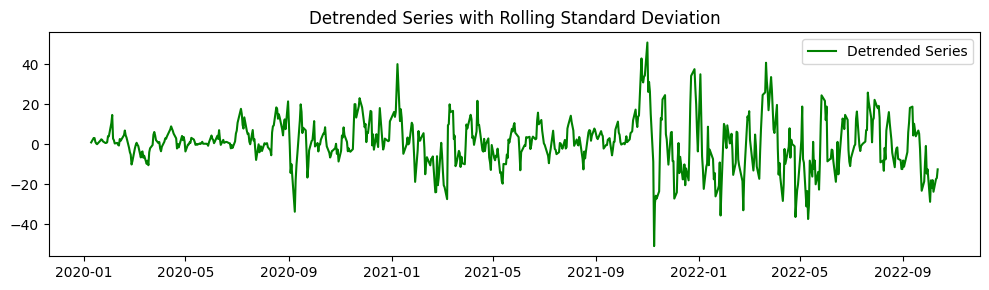

In [ ]:
def _detrended_data(df_train_data, window_size):

    # Assuming your DataFrame is named 'df_train_data' and the time series column is named 'Adj Close'
    data_series = pd.Series(df_train_data['Adj Close'])

    # Perform detrending using moving average
    rolling_mean = data_series.rolling(window_size).mean()
    detrended_data = data_series - rolling_mean

    # Plotting the original time series, the detrended series, and rolling standard deviation
    plt.figure(figsize=(10, 3))
    plt.plot(df_train_data.index, detrended_data, label='Detrended Series', color='green')
    plt.title('Detrended Series with Rolling Standard Deviation')
    plt.legend()

    plt.tight_layout()
    plt.show()

window_size=7
_detrended_data(df_train_data, window_size)

###2.4.4. Decomposition

####Step 9e: Decomposition ( Additive and Multiplicative Example)

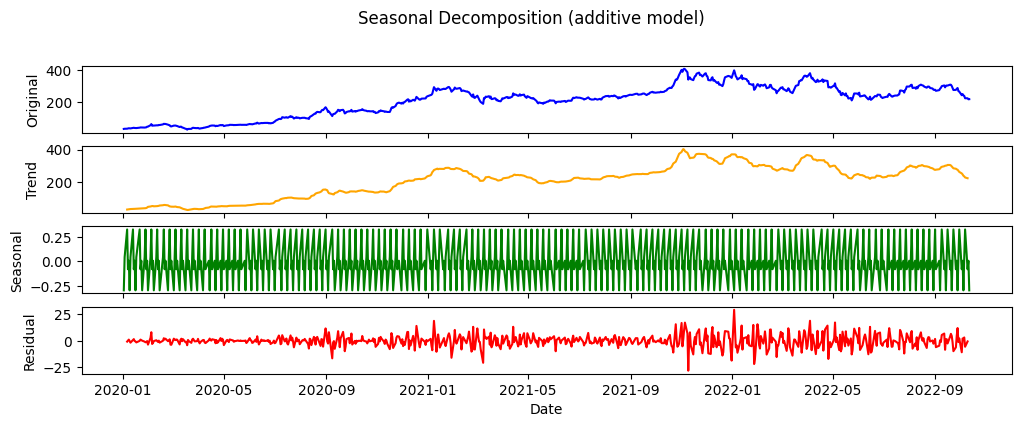

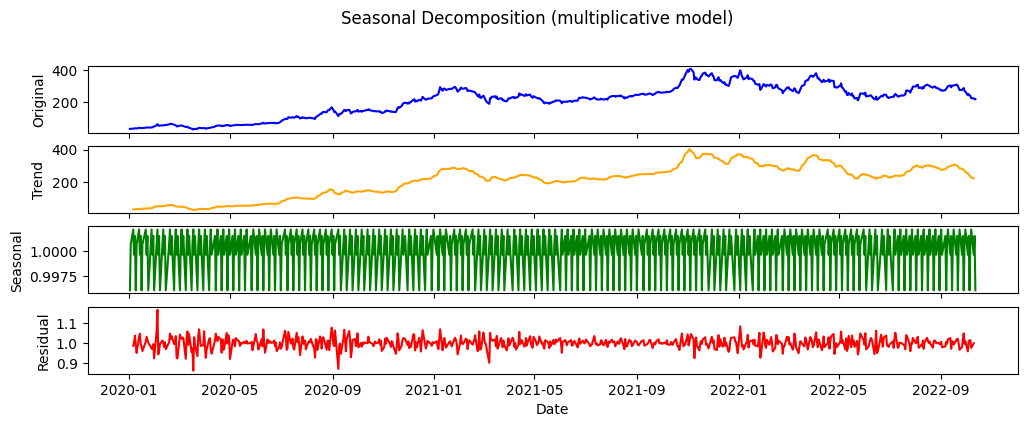

In [ ]:
def visualize_stl(df_train_data, decomposition_type):
    # Ensure that the DataFrame has a datetime index
    df_train_data.index = pd.to_datetime(df_train_data.index)  # Convert the index to datetime

    # Explicitly set the frequency of the index
    df_train_data.index.freq = pd.infer_freq(df_train_data.index)

    # Explicitly specify the period for seasonal decomposition
    period = 5  # Assuming a stock market week seasonality

    # Perform seasonal decomposition
    result = seasonal_decompose(
        df_train_data['Adj Close'],
        model=decomposition_type,
        period=period
    )

    # Plot each component in separate subplots
    fig, axes = plt.subplots(4, 1, figsize=(12, 4), sharex=True)

    # Plot the original time series
    axes[0].plot(df_train_data.index, df_train_data['Adj Close'], label='Original', color='blue')
    axes[0].set_ylabel('Original')

    # Plot the trend component
    axes[1].plot(df_train_data.index, result.trend, label='Trend', color='orange')
    axes[1].set_ylabel('Trend')

    # Plot the seasonal component
    axes[2].plot(df_train_data.index, result.seasonal, label='Seasonal', color='green')
    axes[2].set_ylabel('Seasonal')

    # Plot the residual component
    axes[3].plot(df_train_data.index, result.resid, label='Residual', color='red')
    axes[3].set_ylabel('Residual')

    plt.xlabel('Date')
    plt.suptitle(f'Seasonal Decomposition ({decomposition_type} model)', y=1.02)
    plt.show()

# Assuming df_train_data is your DataFrame with 'Date' as a column and 'Adj Close' as a column
visualize_stl(df_train_data, decomposition_type='additive')
visualize_stl(df_train_data, decomposition_type='multiplicative')

###2.4.5. Adjustments

####Step 9f: Adjustments

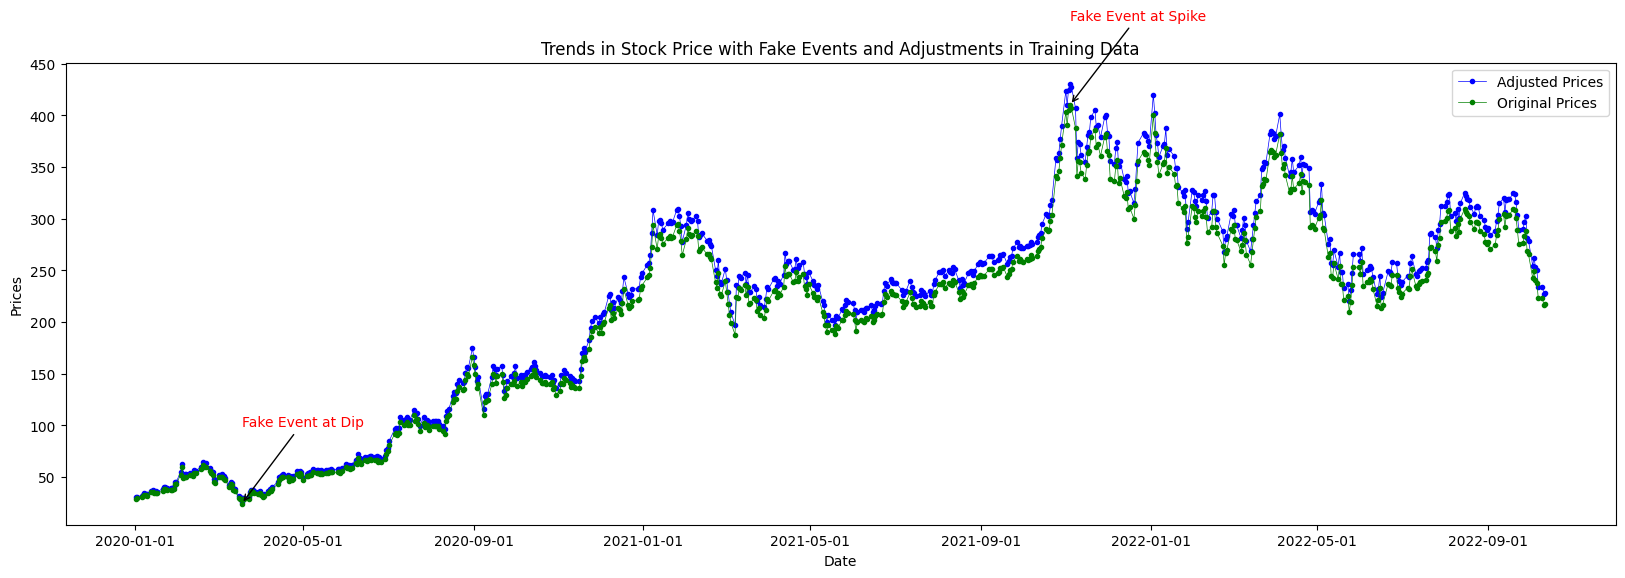

In [ ]:
def _visualize_adjusted_prices(df_train_data):

    # Exxagerated inflation factor
    inflation_factor = 1.05

    # Create a variable 'adjusted_prices' containing the inflation-adjusted prices
    adjusted_prices = df_train_data['Adj Close'] * inflation_factor

    # Create fake events for training data at spikes or dips
    fake_events = [
        (df_train_data['Adj Close'].idxmax(), 'Fake Event at Spike'),
        (df_train_data['Adj Close'].idxmin(), 'Fake Event at Dip')
    ]

    # Plot training data
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Adjust the format as needed

    if adjusted_prices is not None:
        ax.plot(df_train_data.index, adjusted_prices, color='blue', marker='.', linestyle='-', linewidth=0.5, label='Adjusted Prices')

    ax.plot(df_train_data.index, df_train_data['Adj Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Original Prices')

    # Plot fake events on the training data plot
    for event_date, event_label in fake_events:
        if 'Spike' in event_label:
            ax.annotate(event_label, xy=(event_date, df_train_data['Adj Close'].max()), xytext=(event_date, df_train_data['Adj Close'].max() * 1.2),
                        arrowprops=dict(facecolor='black', arrowstyle='->'), color='red')
        else:
            ax.annotate(event_label, xy=(event_date, df_train_data['Adj Close'].min()), xytext=(event_date, df_train_data['Adj Close'].min() * 4.1),
                        arrowprops=dict(facecolor='black', arrowstyle='->'), color='red')

    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Prices')
    ax.set_title('Trends in Stock Price with Fake Events and Adjustments in Training Data')

# Now, you can use the _visualize_adjusted_prices function with the adjusted prices
_visualize_adjusted_prices(df_train_data)


###2.4.6. Smoothing

####Step 9g: Smoothing

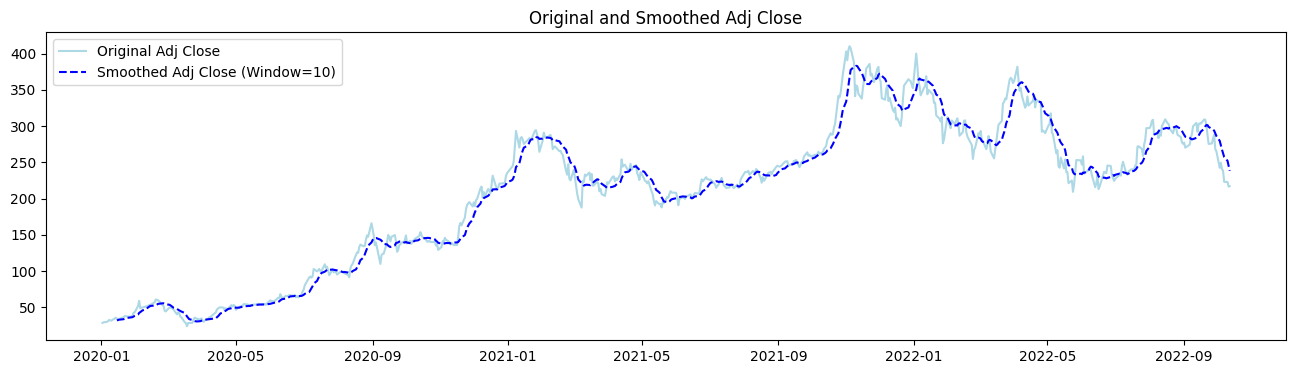

In [ ]:
def visualize_smoothed_curve(df_train_data):
    window_size = 10

    # Original Time Series
    original_curve = df_train_data['Adj Close']

    # Smoothed Curves
    smoothed_adj_close = original_curve.rolling(window=window_size).mean()

    # Plotting
    plt.figure(figsize=(16, 4))

    # Original Time Series
    plt.plot(df_train_data.index, original_curve, label='Original Adj Close', color='lightblue')

    # Smoothed Curve
    plt.plot(df_train_data.index, smoothed_adj_close, label=f'Smoothed Adj Close (Window={window_size})', color='blue', linestyle='--')

    plt.title('Original and Smoothed Adj Close')
    plt.legend()
    plt.show()


visualize_smoothed_curve(df_train_data)


###2.4.7. Transformations

####Step 9h: Log and Box-cox Transformations

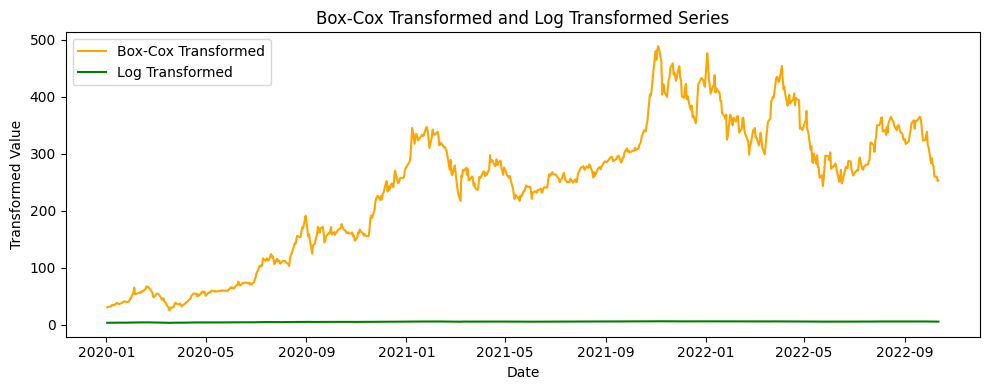

In [ ]:
# Assuming df_train_data is your training DataFrame
df_train_data.index = pd.to_datetime(df_train_data.index)
data = pd.Series(df_train_data['Adj Close'])

# Perform Box-Cox transformation
transformed_data_boxcox, lambda_value_boxcox = stats.boxcox(data)

# Perform log transformation
transformed_data_log = data.apply(lambda x: 0 if x == 0 else np.log(x))

# Plot the original time series, Box-Cox transformed series, and log-transformed series
plt.figure(figsize=(10, 4))
plt.plot(data.index, transformed_data_boxcox, label='Box-Cox Transformed', color='orange')
plt.plot(data.index, transformed_data_log, label='Log Transformed', color='green')

plt.title('Box-Cox Transformed and Log Transformed Series')
plt.xlabel('Date')
plt.ylabel('Transformed Value')
plt.legend()
plt.tight_layout()
plt.show()

##2.5. Forecast using baseline model

### 2.5.1 Statistical Methods

In [ ]:
!pip install arch
!pip install pmdarima

####################################################################################################

                                       Models for Time-series                                       

####################################################################################################

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=11.35 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=6448.072, Time=0.12 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=6163.390, Time=1.02 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=5.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=6448.474, Time=0.16 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=6102.619, Time=2.82 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=25.36 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=8.62 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=6101.126, Time=1.55 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=6162.371, Time=0.51 sec

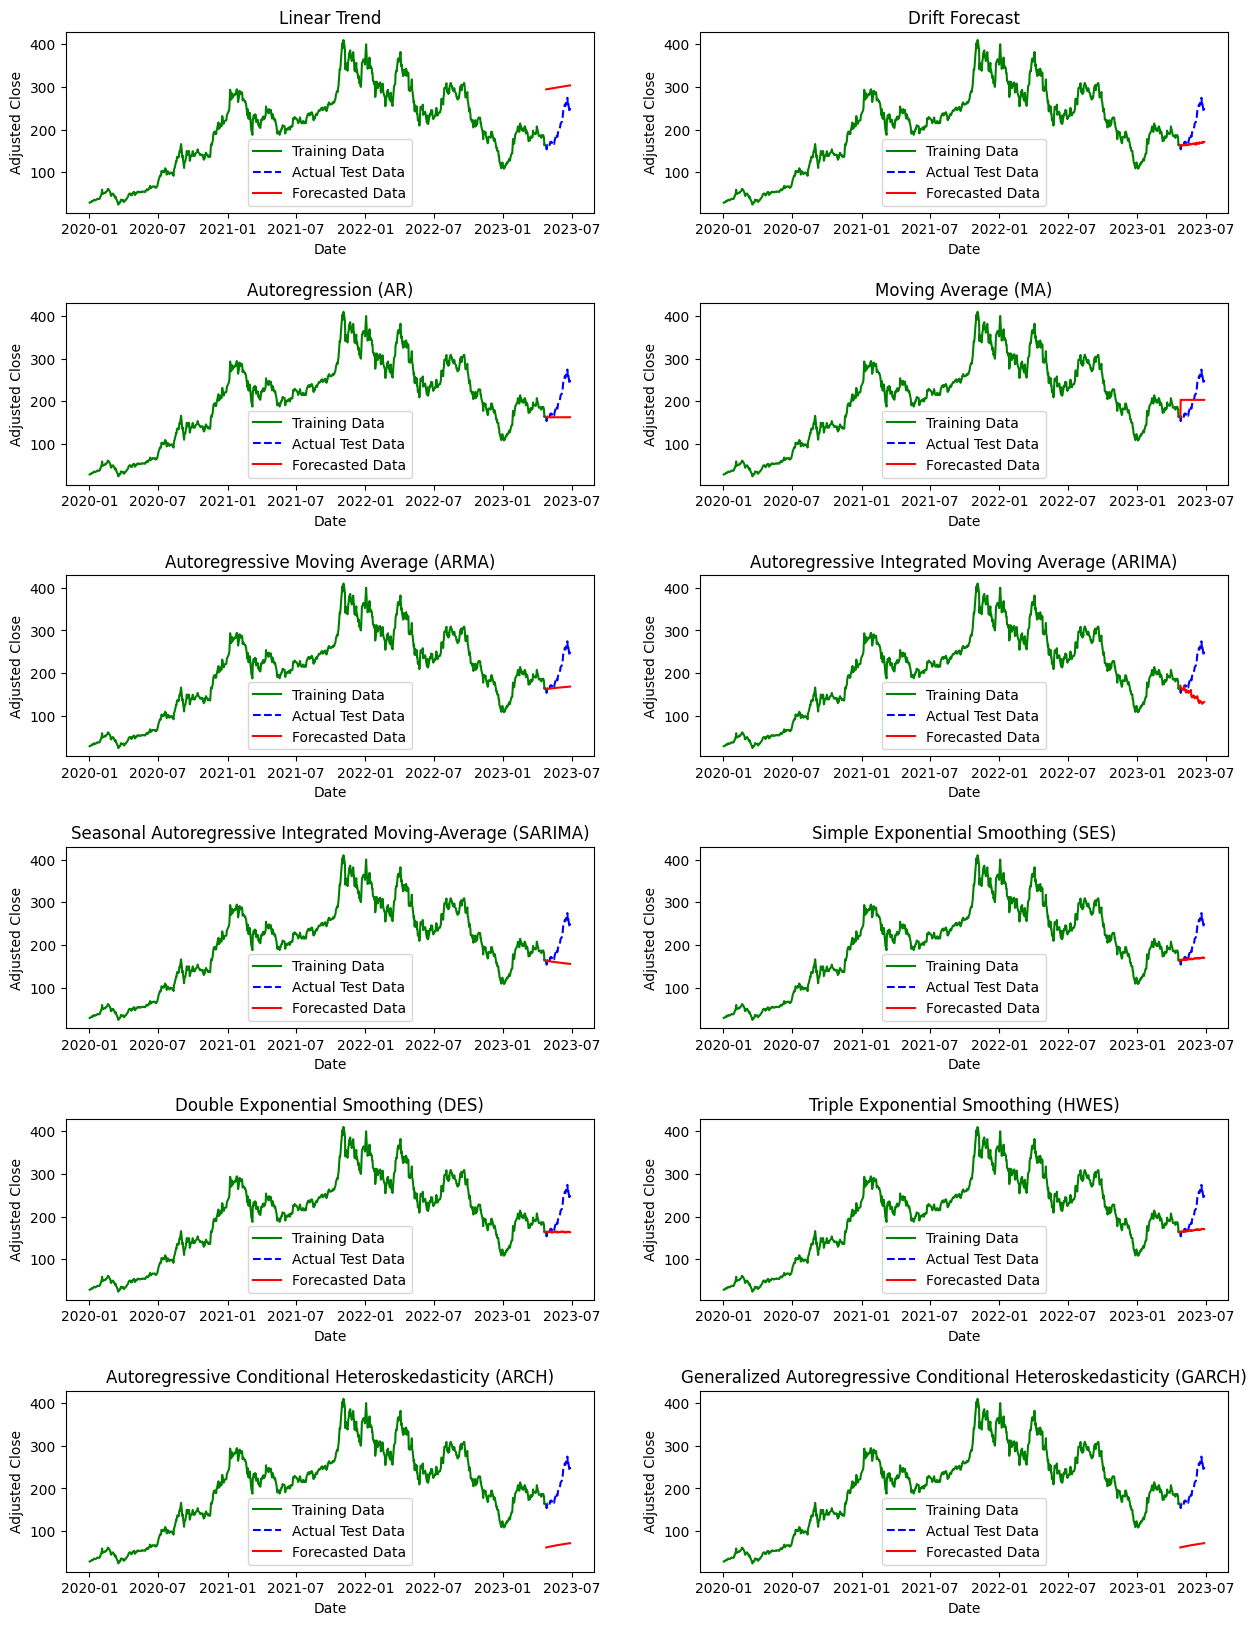

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S3_Ch14_Timeseries.csv'
    dataLink = 'https://drive.google.com/open?id=16r63v-Ctdb1kmE_hGbKrctY4qnGBRznq'   # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)

    return df_rawdata

def _2_splitdata(timeseries_df):
    timeseries_df = timeseries_df.sort_index()  # Sort the dataframe by index (assuming 'Date' is the index)
    timeseries_df['Date'] = pd.to_datetime(timeseries_df['Date'])
    timeseries_df = timeseries_df[timeseries_df['Date'] >= '2020-01-01']

    timeseries_df.set_index('Date', inplace=True)

    data_series = timeseries_df['Adj Close']
    train_size_lim = int(len(data_series) * 0.95)

    df_train_data = timeseries_df.iloc[0:train_size_lim]
    df_test_data = timeseries_df.iloc[train_size_lim:]

    return df_train_data, df_test_data

def plot_forecast(ax, train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, title):
    # Plot the original training data
    ax.plot(train_series.index, train_series, label='Training Data', color='green')

    # Plot the actual test data in blue
    if test_series is not None:
        test_index = test_series.index
        ax.plot(test_index, test_series[:len(test_series)], label='Actual Test Data', linestyle='--', color='blue')

        # Plot the forecasted data in red
        ax.plot(test_index, forecast_series[:len(forecast_series)], label='Forecasted Data', linestyle='-', color='red')

    # Zoom in on the forecasted period
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close')
    ax.legend()
    ax.set_title(title)

def linear_trend_model(train_series, test_series, forecast_start_date, forecast_end_date, forecast_steps, result_df):
    model_name = 'Linear Trend'

    # 0. Start the timer
    start_time = time.time()
    model = LinearRegression()
    X = np.arange(len(train_series)).reshape(-1, 1)
    fitted_model = model.fit(X, train_series)

    # Generate forecast for the specified number of steps
    training_start_date = min(train_series.index)
    training_end_date = max(train_series.index)
    forecast_freq = train_series.index.freq if train_series.index.freq else 'D'  # Use a default frequency if not available

    forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=forecast_freq)

    # Extend the X array for the forecasted values
    extended_X = np.arange(len(train_series), len(train_series) + len(forecast_steps)).reshape(-1, 1)

    # Update forecast to align with the test data
    forecast_series = model.predict(extended_X)[:len(test_series)]

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Append the results to result_df
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, fitted_model)

    # Create a new time index for the forecast
    forecast_start_date = min(train_series.index)
    forecast_end_date = forecast_index[-1]
    # forecast_time_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=forecast_freq)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def drift_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Drift Forecast'
    # 0. Start the timer
    start_time = time.time()

    # Assuming drift is a constant value calculated from the training data
    drift = (train_series.iloc[-1] - train_series.iloc[0]) / len(train_series)

    # # Ensure that forecast_index is used correctly
    forecast_steps = len(test_series)

    forecast_series = train_series.iloc[-1] + drift * np.arange(1, forecast_steps + 1)

    # Generate random noise with the same length as the forecast series
    random_noise = np.random.normal(0, 1, size=len(forecast_series))

    # Apply the drift and add the random noise
    forecast_series = train_series.iloc[-1] + drift * np.arange(1, forecast_steps + 1) + random_noise

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]

    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def ar_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Autoregression (AR)'
    # 0. Start the timer
    start_time = time.time()

    # Replace the following lines with your chosen model (e.g., AR, MA, ARMA, ARIMA)
    ar_model = ARIMA(train_series, order=(1, 0, 0))

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = ar_model.fit().get_forecast(steps=len(test_series)).predicted_mean

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def ma_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Moving Average (MA)'
    # 0. Start the timer
    start_time = time.time()

    # Replace the following lines with your chosen model (e.g., AR, MA, ARMA, ARIMA)
    ma_model = ARIMA(train_series, order=(0, 0, 1))

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = ma_model.fit().get_forecast(steps=len(test_series)).predicted_mean

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def arma_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Autoregressive Moving Average (ARMA)'
    # 0. Start the timer
    start_time = time.time()

    # Replace the following lines with your chosen model (e.g., AR, MA, ARMA, ARIMA)
    arma_model = ARIMA(train_series, order=(1, 0, 1))

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = arma_model.fit().get_forecast(steps=len(test_series)).predicted_mean

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

# def arima_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
#     model_name = 'Autoregressive Integrated Moving Average (ARIMA)'
#     # 0. Start the timer
#     start_time = time.time()

#     # Replace the following lines with your chosen model (e.g., AR, MA, ARMA, ARIMA)
#     arima_model = ARIMA(train_series, order=(1, 1, 1))

#     with warnings.catch_warnings():
#         warnings.filterwarnings("ignore")
#         forecast_series = arima_model.fit().get_forecast(steps=len(test_series)).predicted_mean

#     end_time = time.time()
#     duration = round(end_time - start_time, ndigits=4)

#     # Trim forecast_series to match the length of test_series
#     forecast_series = forecast_series[:len(test_series)]
#     result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

#     return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df



def arima_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Autoregressive Integrated Moving Average (ARIMA)'
    # 0. Start the timer
    start_time = time.time()

    # Fit auto-ARIMA model
    arima_model = auto_arima(train_series, start_p=1, start_q=1,
                             max_p=3, max_q=3, m=12,  # Seasonal parameters (if any)
                             start_P=0, seasonal=True,
                             d=None, D=1, trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)  # set to stepwise

    # Forecast
    forecast_series = arima_model.predict(n_periods=len(test_series))

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df


def sarima_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Seasonal Autoregressive Integrated Moving-Average (SARIMA)'
    # 0. Start the timer
    start_time = time.time()

    # Replace the following lines with your chosen model (e.g., AR, MA, ARMA, ARIMA)
    sarima_model = SARIMAX(train_series, order=(1, 0, 1), seasonal_order=(1, 0, 1, 2))

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = sarima_model.fit().get_forecast(steps=len(test_series)).predicted_mean

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def ses_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Simple Exponential Smoothing (SES)'
    # 0. Start the timer
    start_time = time.time()

    ses_model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=12)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = ses_model.fit().forecast(steps=len(test_series))

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def des_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Double Exponential Smoothing (DES)'
    # 0. Start the timer
    start_time = time.time()

    des_model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=12, damped=True)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = des_model.fit().forecast(steps=len(test_series))

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def hwes_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Triple Exponential Smoothing (HWES)'
    # 0. Start the timer
    start_time = time.time()

    hwes_model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=12, use_boxcox=True)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        forecast_series = hwes_model.fit().forecast(steps=len(test_series))

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = forecast_series[:len(test_series)]
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def arch_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_steps, result_df):
    model_name = 'Autoregressive Conditional Heteroskedasticity (ARCH)'

    # 0. Start the timer
    start_time = time.time()

    arch_model_instance = arch_model(train_series, vol='Garch', p=1, q=1)

    # Fit the model
    fitted_model = arch_model_instance.fit(disp='off')

    # Forecast future volatility
    forecast_steps = max(len(df_test_data), 1)  # Ensure forecast_steps is at least 1
    forecast_volatility = fitted_model.forecast(start=None, horizon=forecast_steps)

    # Generate forecast index
    forecast_index = pd.date_range(start=train_series.index[-1], periods=forecast_steps + 1, freq=train_series.index.freq)[1:]

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = pd.Series(np.sqrt(forecast_volatility.variance.values[-1, :]), index=forecast_index)

    # Assuming you have a function append_result_df
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, fitted_model)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df

def garch_method(train_series, test_series, forecast_start_date, forecast_end_date, forecast_index, result_df):
    model_name = 'Generalized Autoregressive Conditional Heteroskedasticity (GARCH)'
    # 0. Start the timer
    start_time = time.time()

    garch_model = arch_model(train_series, vol='Garch', p=1, q=1)

    # Forecast future volatility
    forecast_volatility = garch_model.fit(disp='off').forecast(start=None, horizon=forecast_steps)
    forecast_index = pd.date_range(start=train_series.index[-1], periods=forecast_steps + 1, freq=train_series.index.freq)[1:]

    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)

    # Trim forecast_series to match the length of test_series
    forecast_series = pd.Series(np.sqrt(forecast_volatility.variance.values[-1, :]), index=forecast_index)
    result_df = append_result_df(result_df, data, model_name, "Baseline", 1, test_series, forecast_series, duration, None)

    return train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date, model_name, result_df


def create_result_df():
    result_df = pd.DataFrame(columns=['Data', 'Algorithm', 'Model_Changed', 'Iteration', 'MAE', 'MSE',
                                      'RMSE', 'MAPE', 'SMAPE','duration'])
    return result_df

def append_result_df(result_df, data, model_name, model_change, iteration_number, y_true, y_pred, duration, fitted_model):
    result_row = {
        'Data': "Test",
        'Algorithm': model_name,
        'Model_Changed': model_change,
        'Iteration': iteration_number,
        'duration': duration
    }

    if y_true is not None and y_pred is not None:

        result_row['MAE'] = round(mean_absolute_error(y_true, y_pred),2)
        result_row['MSE'] = round(mean_squared_error(y_true, y_pred),2)
        result_row['RMSE'] = round(np.sqrt(mean_squared_error(y_true, y_pred)),2)
        # Check if y_true and y_pred are iterable and not scalar values
        if hasattr(y_true, '__iter__') and hasattr(y_pred, '__iter__'):
            # Check if all values are non-negative
            if (np.array(y_true) >= 0).all() and (np.array(y_pred) >= 0).all():
                # Only calculate these metrics if all values are non-negative
                result_row['MAPE'] = round(mean_absolute_percentage_error(y_true, y_pred),2)  # Use sklearn for MAPE
                result_row['SMAPE'] = round(pm_metrics.smape(y_true, y_pred),2)  # Use pm_metrics for SMAPE
            else:
                # If any value is negative, set these metrics to NaN or a custom value
                result_row['MAPE'] = None
                result_row['SMAPE'] = None

            result_df = pd.concat([result_df, pd.DataFrame(result_row, index=[0])], ignore_index=True)

    return result_df


def _train_model(df_train_data, df_test_data, result_df, forecast_steps):

    # Printing header
    print_pretty_header("Models for Time-series", "")

    # Create a 2x2 grid of diagnostic plots
    fig, axs = plt.subplots(6, 2, figsize=(15, 20))
    fig.subplots_adjust(hspace=0.5)

    # Forecast for the entire test data period
    forecast_start_date = min(df_test_data.index)
    forecast_end_date = max(df_test_data.index)
    forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')

    # Extract relevant portion of y_true
    y_true = df_test_data['Adj Close']

    models = [
          'Linear Trend',
          'Drift Method',
          'Autoregression (AR)',
          'Moving Average (MA)',
          'Autoregressive Moving Average (ARMA)',
          'Autoregressive Integrated Moving Average (ARIMA)',
          'Seasonal Autoregressive Integrated Moving-Average (SARIMA)',
          # 'Seasonal Autoregressive Integrated Moving-Average with Exogenous Regressors (SARIMAX)',
          'Simple Exponential Smoothing (SES)',
          'Double Exponential Smoothing (DES)',
          'Triple Exponential Smoothing (HWES)',
          'Autoregressive Conditional Heteroskedasticity (ARCH)',
          'Generalized Autoregressive Conditional Heteroskedasticity (GARCH)'
    ]

    for i, model_name in enumerate(models):

        if model_name == 'Linear Trend':
            linear_trend_train_series, linear_trend_test_series, linear_trend_model_forecast_series, linear_trend_forecast_index, linear_trend_forecast_start_date, linear_trend_forecast_end_date, linear_trend_title, result_df = linear_trend_model(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], linear_trend_train_series, linear_trend_test_series, linear_trend_model_forecast_series, linear_trend_forecast_index, linear_trend_forecast_start_date, linear_trend_forecast_end_date, linear_trend_title)

        elif model_name == 'Drift Method':
            drift_method_train_series, drift_method_test_series, drift_method_model_forecast_series, drift_method_forecast_index, drift_method_forecast_start_date, drift_method_forecast_end_date, drift_method_title, result_df = drift_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], drift_method_train_series, drift_method_test_series, drift_method_model_forecast_series, drift_method_forecast_index, drift_method_forecast_start_date, drift_method_forecast_end_date, drift_method_title)

        elif model_name ==  'Autoregression (AR)':
            ar_method_train_series, ar_method_test_series, ar_method_model_forecast_series, ar_method_forecast_index, ar_method_forecast_start_date, ar_method_forecast_end_date, ar_method_title,result_df = ar_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2],ar_method_train_series, ar_method_test_series, ar_method_model_forecast_series, ar_method_forecast_index, ar_method_forecast_start_date, ar_method_forecast_end_date, ar_method_title)

        elif model_name ==  'Moving Average (MA)':
            ma_method_train_series, ma_method_test_series, ma_method_model_forecast_series, ma_method_forecast_index, ma_method_forecast_start_date, ma_method_forecast_end_date, ma_method_title, result_df = ma_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2],ma_method_train_series, ma_method_test_series, ma_method_model_forecast_series, ma_method_forecast_index, ma_method_forecast_start_date, ma_method_forecast_end_date, ma_method_title)

        elif model_name ==  'Autoregressive Moving Average (ARMA)':
           arma_method_train_series, arma_method_test_series, arma_method_model_forecast_series, arma_method_forecast_index, arma_method_forecast_start_date, arma_method_forecast_end_date, arma_method_title,result_df = arma_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
           plot_forecast(axs[i // 2, i % 2],arma_method_train_series, arma_method_test_series, arma_method_model_forecast_series, arma_method_forecast_index, arma_method_forecast_start_date, arma_method_forecast_end_date, arma_method_title)

        elif model_name ==  'Autoregressive Integrated Moving Average (ARIMA)':
            arima_method_train_series, arima_method_test_series, arima_method_model_forecast_series, arima_method_forecast_index, arima_method_forecast_start_date, arima_method_forecast_end_date, arima_method_title,result_df = arima_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], arima_method_train_series, arima_method_test_series, arima_method_model_forecast_series, arima_method_forecast_index, arima_method_forecast_start_date, arima_method_forecast_end_date, arima_method_title)

        elif model_name ==  'Seasonal Autoregressive Integrated Moving-Average (SARIMA)':
            sarima_method_train_series, sarima_method_test_series, sarima_method_model_forecast_series, sarima_method_forecast_index, sarima_method_forecast_start_date, sarima_method_forecast_end_date, sarima_method_title, result_df = sarima_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2],sarima_method_train_series, sarima_method_test_series, sarima_method_model_forecast_series, sarima_method_forecast_index, sarima_method_forecast_start_date, sarima_method_forecast_end_date, sarima_method_title)

        elif model_name ==  'Simple Exponential Smoothing (SES)':
            ses_method_train_series, ses_method_test_series, ses_method_model_forecast_series, ses_method_forecast_index, ses_method_forecast_start_date, ses_method_forecast_end_date, ses_method_title, result_df  = ses_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2],ses_method_train_series, ses_method_test_series, ses_method_model_forecast_series, ses_method_forecast_index, ses_method_forecast_start_date, ses_method_forecast_end_date, ses_method_title)

        elif model_name ==  'Double Exponential Smoothing (DES)':
            des_method_train_series, des_method_test_series, des_method_model_forecast_series, des_method_forecast_index, des_method_forecast_start_date, des_method_forecast_end_date, des_method_title, result_df  = des_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], des_method_train_series, des_method_test_series, des_method_model_forecast_series, des_method_forecast_index, des_method_forecast_start_date, des_method_forecast_end_date, des_method_title)

        elif model_name ==  'Triple Exponential Smoothing (HWES)':
            hwes_method_train_series, hwes_method_test_series, hwes_method_model_forecast_series, hwes_method_forecast_index, hwes_method_forecast_start_date, hwes_method_forecast_end_date, hwes_method_title, result_df  = hwes_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], hwes_method_train_series, hwes_method_test_series, hwes_method_model_forecast_series, hwes_method_forecast_index, hwes_method_forecast_start_date, hwes_method_forecast_end_date, hwes_method_title)

        elif model_name ==  'Autoregressive Conditional Heteroskedasticity (ARCH)':
            arch_method_train_series, arch_method_test_series, arch_method_model_forecast_series, arch_method_forecast_index, arch_method_forecast_start_date, arch_method_forecast_end_date, arch_method_title, result_df  = arch_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], arch_method_train_series, arch_method_test_series, arch_method_model_forecast_series, arch_method_forecast_index, arch_method_forecast_start_date, arch_method_forecast_end_date, arch_method_title)

        elif model_name ==  'Generalized Autoregressive Conditional Heteroskedasticity (GARCH)':
            garch_method_train_series, garch_method_test_series, garch_method_model_forecast_series, garch_method_forecast_index, garch_method_forecast_start_date, garch_method_forecast_end_date, garch_method_title, result_df  = garch_method(df_train_data['Adj Close'], y_true, forecast_start_date, forecast_end_date, forecast_index, result_df)
            plot_forecast(axs[i // 2, i % 2], garch_method_train_series, garch_method_test_series, garch_method_model_forecast_series, garch_method_forecast_index, garch_method_forecast_start_date, garch_method_forecast_end_date, garch_method_title)

        else:
            print("No Function defined")

    return result_df

if __name__ == "__main__":
    timeseries_df = _1_get_data()
    df_train_data, df_test_data = _2_splitdata(timeseries_df)

    result_df = create_result_df()
    forecast_steps = len(df_test_data)

    result_df = _train_model(df_train_data, df_test_data, result_df, forecast_steps)
    result_df


In [ ]:
result_df

,Data,Algorithm,Model_Changed,Iteration,MAE,MSE,RMSE,MAPE,SMAPE,duration
0,Test,Linear Trend,Baseline,1,96.55,10585.96,102.89,0.53,39.91,0.0050
1,Test,Drift Forecast,Baseline,1,37.34,2600.60,51.00,0.16,18.53,0.0002
2,Test,Autoregression (AR),Baseline,1,40.46,3016.60,54.92,0.17,20.35,0.1955
3,Test,Moving Average (MA),Baseline,1,33.49,1415.65,37.63,0.17,16.38,0.3140
4,Test,Autoregressive Moving Average (ARMA),Baseline,1,37.71,2678.92,51.76,0.16,18.73,0.8505
5,Test,Autoregressive Integrated Moving Average (ARIMA),Baseline,1,54.87,5344.97,73.11,0.24,29.45,78.1305
6,Test,Seasonal Autoregressive Integrated Moving-Aver...,Baseline,1,43.98,3486.00,59.04,0.19,22.48,0.9234
7,Test,Simple Exponential Smoothing (SES),Baseline,1,36.71,2563.45,50.63,0.16,18.15,0.2273
8,Test,Double Exponential Smoothing (DES),Baseline,1,39.58,2917.51,54.01,0.17,19.83,0.2353
9,Test,Triple Exponential Smoothing (HWES),Baseline,1,36.25,2507.81,50.08,0.15,17.89,0.2377


### 2.5.2 ML Methods

1/1 [==============================] - 2s 2s/step


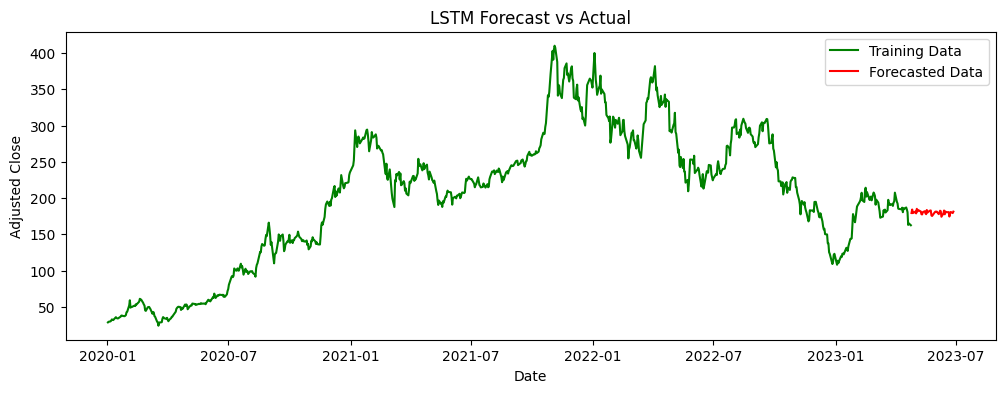

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SARIMAX
from pmdarima import metrics as pm_metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from arch import arch_model
from itertools import zip_longest
from sklearn.linear_model import LinearRegression
import warnings
import time
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Suppress all warnings
warnings.filterwarnings("ignore")

df_train_data = None
df_test_data = None

# ***** Function to help display *****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width) + "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S3_Ch14_Timeseries.csv'
    dataLink = 'https://drive.google.com/open?id=16r63v-Ctdb1kmE_hGbKrctY4qnGBRznq'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)

    return df_rawdata

def _2_splitdata(timeseries_df):
    global df_train_data, df_test_data  # Make df_train_data and df_test_data global
    timeseries_df = timeseries_df.sort_index()  # Sort the dataframe by index (assuming 'Date' is the index)
    timeseries_df['Date'] = pd.to_datetime(timeseries_df['Date'])
    timeseries_df = timeseries_df[timeseries_df['Date'] >= '2020-01-01']
    timeseries_df.set_index('Date', inplace=True)

    data_series = timeseries_df['Adj Close']
    train_size_lim = int(len(data_series) * 0.95)

    df_train_data = timeseries_df.iloc[0:train_size_lim]
    df_test_data = timeseries_df.iloc[train_size_lim:]

    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df_train_data['Adj Close'].values.reshape(-1, 1))

    # Create sequences for LSTM
    x_train, y_train = create_sequences(scaled_data, forecast_steps)

    scaled_data = scaler.fit_transform(df_test_data['Adj Close'].values.reshape(-1, 1))

    # Create sequences for LSTM
    x_test, y_test = create_sequences(scaled_data, forecast_steps)
    return x_train, y_train, x_test, y_test


def plot_forecast(train_series, test_series, forecast_series, forecast_index, forecast_start_date, forecast_end_date,
                  title):
    # Increase the width of the plot
    plt.figure(figsize=(12, 4))

    # Plot the original training data
    plt.plot(train_series.index, train_series, label='Training Data', color='green')

    # Plot the actual test data in blue
    if test_series is not None:
        test_index = test_series.index
        # plt.plot(test_index, test_series[:len(test_series)], label='Actual Test Data', linestyle='--', color='blue')

        # Plot the forecasted data in red
        plt.plot(test_index, forecast_series[:len(forecast_series)], label='Forecasted Data', linestyle='-', color='red')

    # Zoom in on the forecasted period
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close')
    plt.legend()
    plt.title(title)

    plt.show()

def create_result_df():
    result_df = pd.DataFrame(columns=['Data', 'Algorithm', 'Model_Changed', 'Iteration', 'MAE', 'MSE',
                                      'RMSE', 'MAPE', 'SMAPE','duration'])
    return result_df

def append_result_df(result_df, data, model_name, model_change, iteration_number, y_true, y_pred, duration, fitted_model):
    result_row = {
        'Data': "Test",
        'Algorithm': model_name,
        'Model_Changed': model_change,
        'Iteration': iteration_number,
        'duration': duration
    }

    if y_true is not None and y_pred is not None:

        # New metrics
        result_row['MAE'] = round(mean_absolute_error(y_true, y_pred),2)
        result_row['MSE'] = round(mean_squared_error(y_true, y_pred),2)
        result_row['RMSE'] = round(np.sqrt(mean_squared_error(y_true, y_pred)),2)

        # Check if y_true and y_pred are iterable and not scalar values
        if hasattr(y_true, '__iter__') and hasattr(y_pred, '__iter__'):
            # Check if all values are non-negative
            if (np.array(y_true) >= 0).all() and (np.array(y_pred) >= 0).all():
                # Only calculate these metrics if all values are non-negative
                result_row['MAPE'] = round(mean_absolute_percentage_error(y_true, y_pred),2)  # Use sklearn for MAPE
                result_row['SMAPE'] = round(pm_metrics.smape(y_true, y_pred),2)  # Use pm_metrics for SMAPE
            else:
                # If any value is negative, set these metrics to NaN or a custom value
                result_row['MAPE'] = None
                result_row['SMAPE'] = None

            result_df = pd.concat([result_df, pd.DataFrame(result_row, index=[0])], ignore_index=True)

    return result_df

def create_sequences(data, sequence_length):
    x, y = [], []

    for i in range(len(data) - sequence_length):
        # Create input sequence
        sequence = data[i:i + sequence_length]
        x.append(sequence)

        # Create target sequence (1 step ahead)
        target = data[i + sequence_length]
        y.append(target)

    if len(x) == 0:
        # Handle the case where the sequence length is greater than the length of the input data
        x = np.array([data[:-1]])
        y = np.array([data[-1]])

    return np.array(x), np.array(y)

def _train_model(x_train, y_train, x_test, y_test, result_df, forecast_steps):
    # Extract relevant portion of y_true
    y_true = df_test_data['Adj Close'].values

    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df_train_data['Adj Close'].values.reshape(-1, 1))

    # Create sequences for LSTM training
    x_train, y_train = create_sequences(scaled_data, forecast_steps)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Train the LSTM model
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dense(units=forecast_steps))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=1, epochs=1)

    # Create sequences for LSTM testing
    x_test, y_test = create_sequences(scaled_data[-forecast_steps - 1:], forecast_steps + 1)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Make predictions on the test set
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions.reshape(-1, 1))

    # Extract only the relevant part of predictions
    predictions = predictions[:forecast_steps]

    # Append results to result dataframe
    result_df = append_result_df(result_df, 'Test', 'LSTM', 'Baseline', 1, y_true, predictions.flatten(), 0, None)

    # Create a DataFrame with dates for predictions
    forecast_index = df_test_data.index[-forecast_steps:]
    forecast_series = pd.Series(predictions.flatten(), index=forecast_index, name='Forecast')

    # Plot the forecast against the true values
    plot_forecast(df_train_data['Adj Close'], df_test_data['Adj Close'], forecast_series,
                  forecast_index, forecast_index[0], forecast_index[-1], 'LSTM Forecast vs Actual')

    return result_df

if __name__ == "__main__":
    timeseries_df = _1_get_data()

    x_train, y_train, x_test, y_test = _2_splitdata(timeseries_df)

    result_df = create_result_df()
    forecast_steps = len(df_test_data)

    result_df = _train_model(x_train, y_train, x_test, y_test, result_df, forecast_steps)

    result_df


In [ ]:
result_df

,Data,Algorithm,Model_Changed,Iteration,MAE,MSE,RMSE,MAPE,SMAPE,duration
0,Test,LSTM,Baseline,1,34.2,1986.12,44.57,0.15,16.77,0


------------- End of **S3_Ch14_Timeseries_Code Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------